## Task-3

In [1]:
import pandas as pd

df_AAPL = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\AAPL.csv')
df_AMZN = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\AMZN.csv')
df_GOOG = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\GOOG.csv')
df_META = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\META.csv')
df_NVDA = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\NVDA.csv')


# Function to prepare a single stock DataFrame
def prepare_stock_df(df_stock, name):
    print(f"\n--- Preparing df_{name} ---")
    if 'Date' in df_stock.columns:
        df_stock['Date'] = pd.to_datetime(df_stock['Date'])
        df_stock.set_index('Date', inplace=True)
    else:
        print(f"Warning: 'Date' column not found in df_{name}.")

    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in numeric_cols:
        if col in df_stock.columns:
            df_stock[col] = pd.to_numeric(df_stock[col], errors='coerce')

    # Forward-fill then drop any remaining NaNs
    df_stock.ffill(inplace=True)
    df_stock.dropna(inplace=True)


    return df_stock

# Prepare df_AAPL (which was previously handled in a separate cell) as well as the others
# Ensure df_AAPL is prepared first, as it's used in the next cell's all_trading_days calculation
df_AAPL = prepare_stock_df(df_AAPL, 'AAPL')
print(f"\n--- Processed Info for df_AAPL ---")
df_AAPL.info()

print("\n--- Preparing other stock dataframes (AMZN, GOOG, META, NVDA) ---")

# List of stock dataframes to process (now assumed to be loaded)
stock_dfs = {
    'AMZN': df_AMZN,
    'GOOG': df_GOOG,
    'META': df_META,
    'NVDA': df_NVDA
}

# Apply preparation to each dataframe
for name, df in stock_dfs.items():
    stock_dfs[name] = prepare_stock_df(df, name)
    print(f"\n--- Processed Info for df_{name} ---")
    stock_dfs[name].info()

# Update original dataframes with processed ones (global scope)
globals()['df_AMZN'] = stock_dfs['AMZN']
globals()['df_GOOG'] = stock_dfs['GOOG']
globals()['df_META'] = stock_dfs['META']
globals()['df_NVDA'] = stock_dfs['NVDA']

print("\nAll stock dataframes loaded and prepared.")


--- Preparing df_AAPL ---

--- Processed Info for df_AAPL ---
<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB

--- Preparing other stock dataframes (AMZN, GOOG, META, NVDA) ---

--- Preparing df_AMZN ---

--- Processed Info for df_AMZN ---
<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: flo

In [2]:
import pandas as pd

df_news = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\raw_analyst_ratings.csv')

print("--- Aligning news timestamps to trading days ---")

# Collect all unique trading days from all stock DataFrames
all_trading_days = pd.DatetimeIndex([])
for df_stock in [df_AAPL, df_AMZN, df_GOOG, df_META, df_NVDA]:
    all_trading_days = all_trading_days.union(df_stock.index)

# Sort and get unique trading days
all_trading_days = all_trading_days.sort_values().unique()

# Convert to a Series for easier use with pd.Series.searchsorted
trading_days_series = pd.Series(all_trading_days)

# Ensure df_news 'date' column is datetime and timezone-naive for comparison with trading_days_series
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce').dt.tz_convert(None)

# Drop rows where 'date' is NaT (unparseable or out of range)
df_news.dropna(subset=['date'], inplace=True)

# Function to find the next valid trading day
def get_next_trading_day(news_date, trading_days_series):
    # Find the index where news_date would be inserted to maintain order
    idx = trading_days_series.searchsorted(news_date, side='left')
    # If news_date is past the last trading day, use the last trading day
    if idx >= len(trading_days_series):
        return trading_days_series.iloc[-1]
    # If news_date exactly matches a trading day, use it
    elif trading_days_series.iloc[idx] == news_date:
        return trading_days_series.iloc[idx]
    # Otherwise, use the next trading day
    else:
        return trading_days_series.iloc[idx]

# Apply the function to the 'date' column of df_news
# This operation can be slow for large datasets, consider optimizing if needed
df_news['trading_day'] = df_news['date'].apply(lambda x: get_next_trading_day(x, trading_days_series))

print("News dates aligned to trading days. Displaying first 5 rows with new 'trading_day' column:")
display(df_news[['date', 'trading_day']].head())

print("\nChecking a few examples of alignment for non-trading days:")
# Create some example news dates including weekends and holidays for demonstration
example_news_dates = pd.to_datetime([
    '2020-01-01', # New Year's Day (holiday)
    '2020-01-03', # Friday
    '2020-01-04', # Saturday
    '2020-01-05', # Sunday
    '2020-01-06'  # Monday
])

for dt in example_news_dates:
    aligned_dt = get_next_trading_day(dt, trading_days_series)
    print(f"Original: {dt.date()} -> Aligned Trading Day: {aligned_dt.date()}")

--- Aligning news timestamps to trading days ---
News dates aligned to trading days. Displaying first 5 rows with new 'trading_day' column:


,date,trading_day
0,2020-06-05 14:30:54,2020-06-08
1,2020-06-03 14:45:20,2020-06-04
2,2020-05-26 08:30:07,2020-05-27
3,2020-05-22 16:45:06,2020-05-26
4,2020-05-22 15:38:59,2020-05-26



Checking a few examples of alignment for non-trading days:
Original: 2020-01-01 -> Aligned Trading Day: 2020-01-02
Original: 2020-01-03 -> Aligned Trading Day: 2020-01-03
Original: 2020-01-04 -> Aligned Trading Day: 2020-01-06
Original: 2020-01-05 -> Aligned Trading Day: 2020-01-06
Original: 2020-01-06 -> Aligned Trading Day: 2020-01-06


In [3]:
# Install NLTK if not already installed
!pip install nltk

import nltk
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon (if not already downloaded)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("--- Performing Sentiment Analysis using NLTK VADER ---")

sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment_scores(text):
    if pd.isna(text) or not isinstance(text, str):
        return {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}
    return sia.polarity_scores(text)

# Apply sentiment analysis to the 'headline' column
# This might take some time for a large dataset
df_news['sentiment_scores'] = df_news['headline'].apply(get_sentiment_scores)

# Extract individual sentiment scores into separate columns
df_news['sentiment_neg'] = df_news['sentiment_scores'].apply(lambda x: x['neg'])
df_news['sentiment_neu'] = df_news['sentiment_scores'].apply(lambda x: x['neu'])
df_news['sentiment_pos'] = df_news['sentiment_scores'].apply(lambda x: x['pos'])
df_news['sentiment_compound'] = df_news['sentiment_scores'].apply(lambda x: x['compound'])

# Drop the intermediate 'sentiment_scores' column if no longer needed
df_news.drop(columns=['sentiment_scores'], inplace=True)

print("Sentiment analysis complete. Displaying first 5 rows with new sentiment columns:")
display(df_news[['headline', 'trading_day', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].head())


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\a00928253\AppData\Roaming\nltk_data...


--- Performing Sentiment Analysis using NLTK VADER ---
Sentiment analysis complete. Displaying first 5 rows with new sentiment columns:


,headline,trading_day,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
0,Stocks That Hit 52-Week Highs On Friday,2020-06-08,0.0,1.000,0.000,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-04,0.0,1.000,0.000,0.000
2,71 Biggest Movers From Friday,2020-05-27,0.0,1.000,0.000,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-26,0.0,1.000,0.000,0.000
4,B of A Securities Maintains Neutral on Agilent...,2020-05-26,0.0,0.833,0.167,0.296


In [4]:
print("--- Calculating Daily Stock Returns ---")

stock_dfs_list = [
df_AAPL,
df_AMZN,
df_GOOG,
df_META,
df_NVDA
]

stock_names = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

for i, df_stock in enumerate(stock_dfs_list):
    stock_name = stock_names[i]
    print(f"Calculating daily returns for {stock_name}...")
    # Calculate daily percentage change in closing prices
    df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
    # Fill NaN from first row (no previous day) with 0 or drop, depending on subsequent analysis
    df_stock['Daily_Return_Pct'] = df_stock['Daily_Return_Pct'].fillna(0)
    print(f"First 5 rows of {stock_name} with Daily_Return_Pct:")
    display(df_stock.head())

print("Daily stock returns calculated for all dataframes.")

--- Calculating Daily Stock Returns ---
Calculating daily returns for AAPL...
First 5 rows of AAPL with Daily_Return_Pct:


,Close,High,Low,Open,Volume,Daily_Return_Pct
Date,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,0.000000
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,4.220416
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-1.649399
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-2.160860
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,1.856959


Calculating daily returns for AMZN...
First 5 rows of AMZN with Daily_Return_Pct:


,Close,High,Low,Open,Volume,Daily_Return_Pct
Date,,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000,0.000000
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000,-0.551871
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000,6.104327
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000,-2.022318
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000,1.708189


Calculating daily returns for GOOG...
First 5 rows of GOOG with Daily_Return_Pct:


...

Calculating daily returns for META...
First 5 rows of META with Daily_Return_Pct:


,Close,High,Low,Open,Volume,Daily_Return_Pct
Date,,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,0.000000
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,-10.986138
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,-8.903890
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,3.225802
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,3.218744


Calculating daily returns for NVDA...
First 5 rows of NVDA with Daily_Return_Pct:


,Close,High,Low,Open,Volume,Daily_Return_Pct
Date,,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,0.000000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,1.836972
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,3.382205
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,-5.997831
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,-2.552240


Daily stock returns calculated for all dataframes.


In [5]:
print("--- Aggregating daily sentiment scores for each stock ---")

# Group by trading_day and stock, then calculate the mean of sentiment_compound
daily_sentiment = df_news.groupby(['trading_day', 'stock'])['sentiment_compound'].mean().reset_index()
daily_sentiment.rename(columns={'sentiment_compound': 'avg_daily_sentiment'}, inplace=True)

print("Aggregated daily sentiment scores. Displaying first 5 rows:")
display(daily_sentiment.head())


--- Aggregating daily sentiment scores for each stock ---
Aggregated daily sentiment scores. Displaying first 5 rows:


,trading_day,stock,avg_daily_sentiment
0,2011-04-29,DEJ,0.25
1,2011-04-29,DGP,0.00
2,2011-04-29,ESR,0.00
3,2011-05-02,AIA,0.00
4,2011-05-02,DBP,0.00


In [6]:
print("--- Merging aggregated sentiment with stock daily returns ---")

merged_dfs = {}

for i, df_stock in enumerate(stock_dfs_list):
    stock_name = stock_names[i]

    df_stock_temp = df_stock.copy()
    # Add the current DatetimeIndex as a new column 'trading_day'
    df_stock_temp['trading_day'] = df_stock_temp.index
    # Ensure the 'Daily_Return_Pct' is also a column for selection
    # The index will no longer be implicitly used for merging by position
    
    # Filter daily_sentiment for the current stock
    sentiment_for_stock = daily_sentiment[daily_sentiment['stock'] == stock_name].copy()
    
    # Ensure 'trading_day' in sentiment_for_stock is datetime64[ns]
    sentiment_for_stock.loc[:, 'trading_day'] = pd.to_datetime(sentiment_for_stock['trading_day'])

    # Merge sentiment with stock data on the 'trading_day' column
    merged_df = pd.merge(
        df_stock_temp[['trading_day', 'Daily_Return_Pct']], # Select 'trading_day' as an explicit column
        sentiment_for_stock[['trading_day', 'avg_daily_sentiment']],
        on='trading_day', # Now explicitly merge on this column
        how='inner'
    )
    merged_df.set_index('trading_day', inplace=True)
    merged_dfs[stock_name] = merged_df
    
    print(f"First 5 rows of merged data for {stock_name}:")
    display(merged_df.head())

print("Merging complete for all stocks.")

--- Merging aggregated sentiment with stock daily returns ---
First 5 rows of merged data for AAPL:


,Daily_Return_Pct,avg_daily_sentiment
trading_day,,
2020-06-10,2.572771,0.24690
2020-06-11,-4.801060,0.19885


First 5 rows of merged data for AMZN:


,Daily_Return_Pct,avg_daily_sentiment
trading_day,,
2020-06-10,1.791329,0.077775
2020-06-11,-3.380230,0.391233


First 5 rows of merged data for GOOG:


...

First 5 rows of merged data for META:


,Daily_Return_Pct,avg_daily_sentiment
trading_day,,


First 5 rows of merged data for NVDA:


,Daily_Return_Pct,avg_daily_sentiment
trading_day,,
2020-06-01,-0.780224,0.421500
2020-06-03,-0.631730,0.220200
2020-06-09,2.737033,0.168667
2020-06-10,3.545800,0.729600
2020-06-11,-6.090696,0.243200


Merging complete for all stocks.


--- Calculating and visualizing correlation between sentiment and returns ---


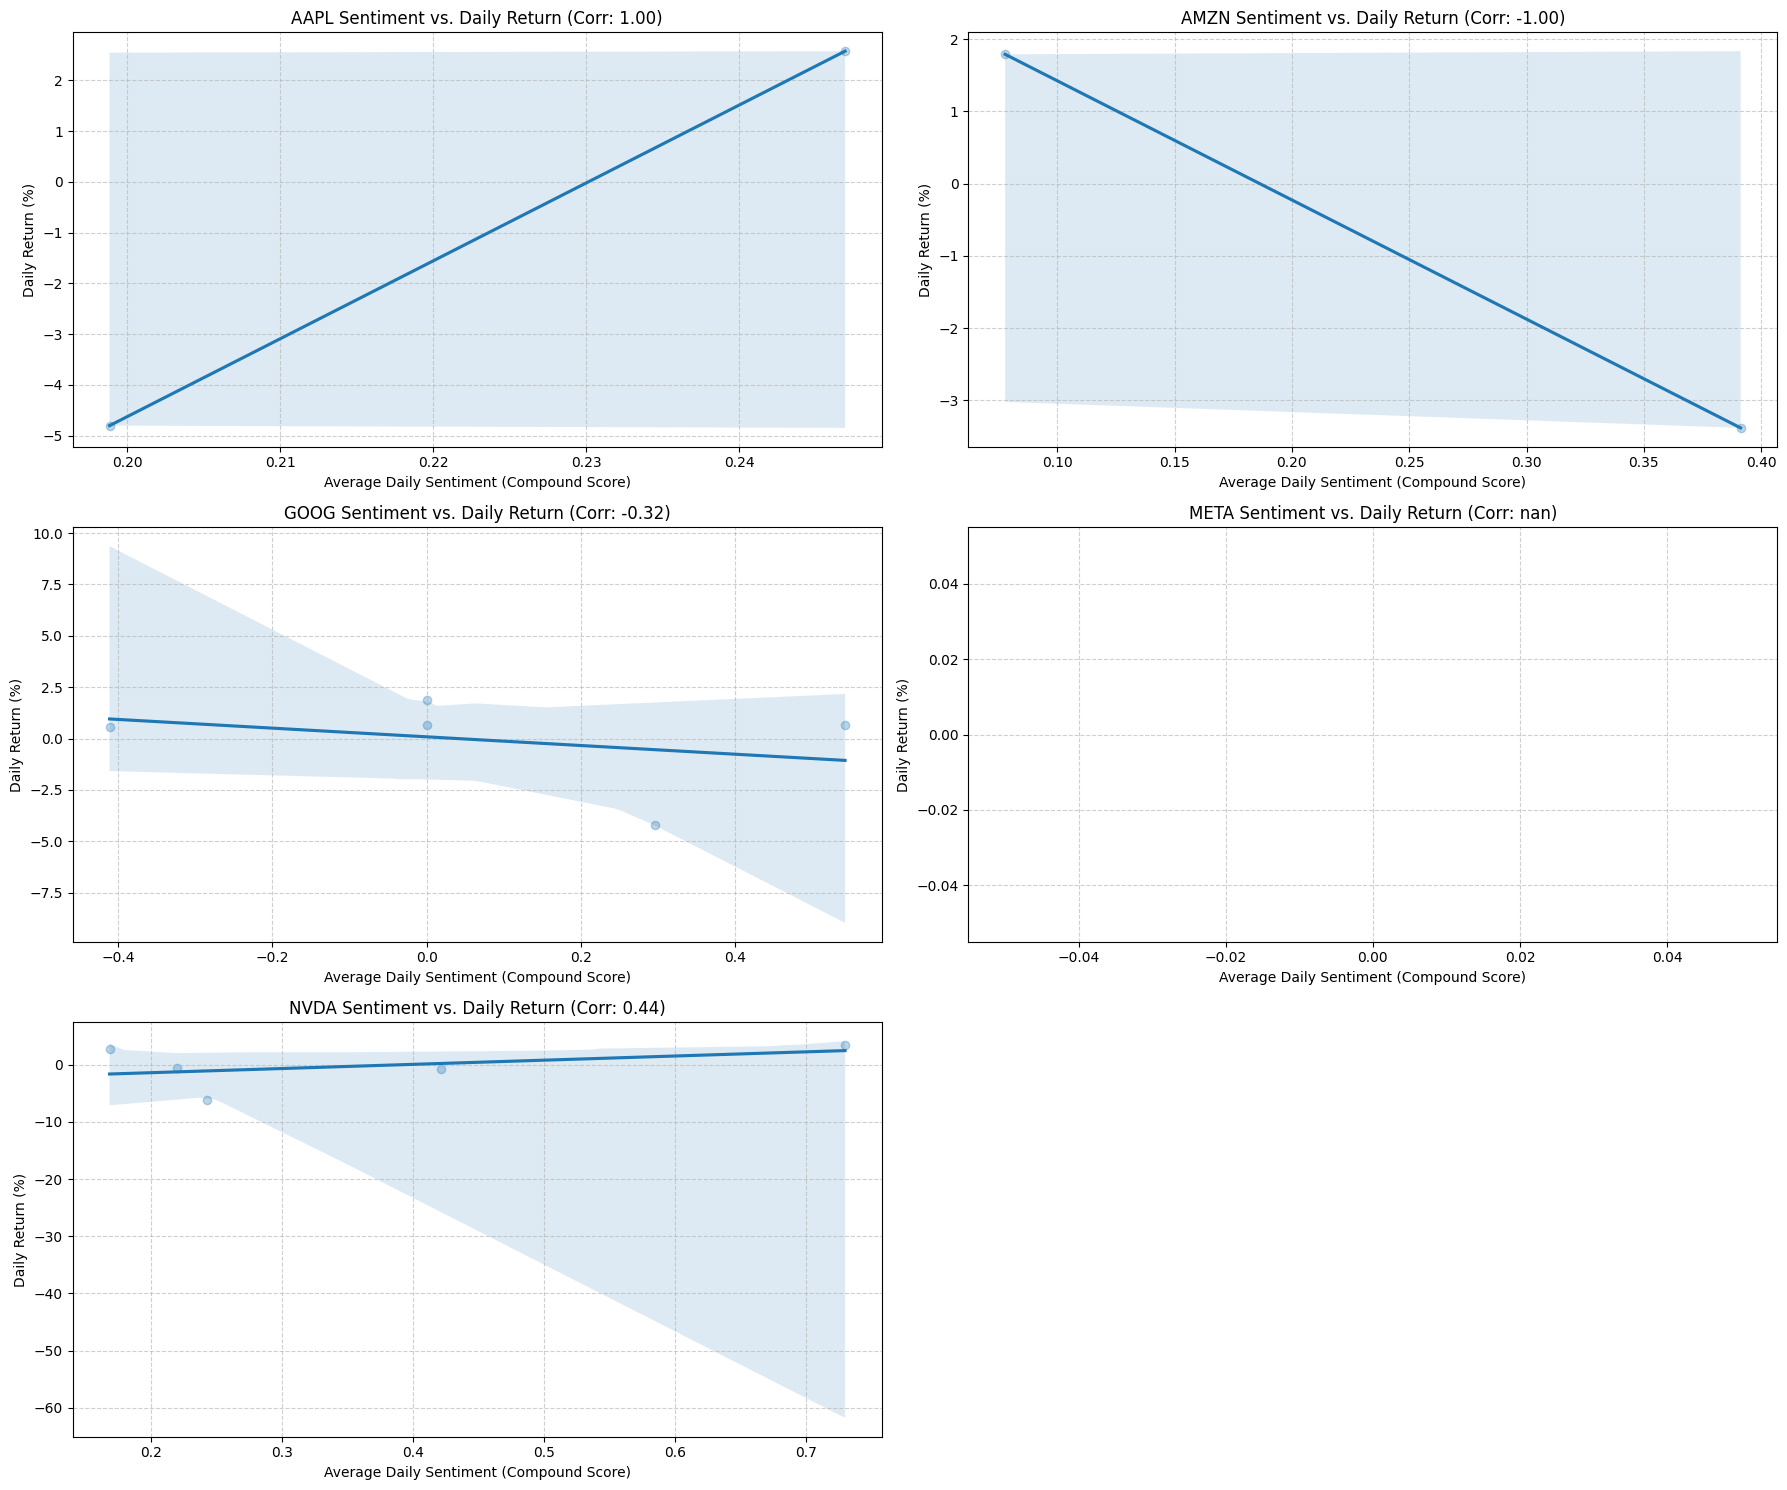

Correlation analysis and visualizations complete.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Calculating and visualizing correlation between sentiment and returns ---")

plt.figure(figsize=(18, 15))

for i, stock_name in enumerate(stock_names):
    merged_df = merged_dfs[stock_name]
    
    # Calculate Pearson correlation
    correlation = merged_df['avg_daily_sentiment'].corr(merged_df['Daily_Return_Pct'])

    # Create scatter plot
    plt.subplot(3, 2, i + 1) # Adjust subplot grid based on number of stocks
    sns.regplot(x='avg_daily_sentiment', y='Daily_Return_Pct', data=merged_df, scatter_kws={'alpha':0.3})
    plt.title(f'{stock_name} Sentiment vs. Daily Return (Corr: {correlation:.2f})')
    plt.xlabel('Average Daily Sentiment (Compound Score)')
    plt.ylabel('Daily Return (%)')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Correlation analysis and visualizations complete.")

--- Classifying sentiment and plotting average daily returns per category ---


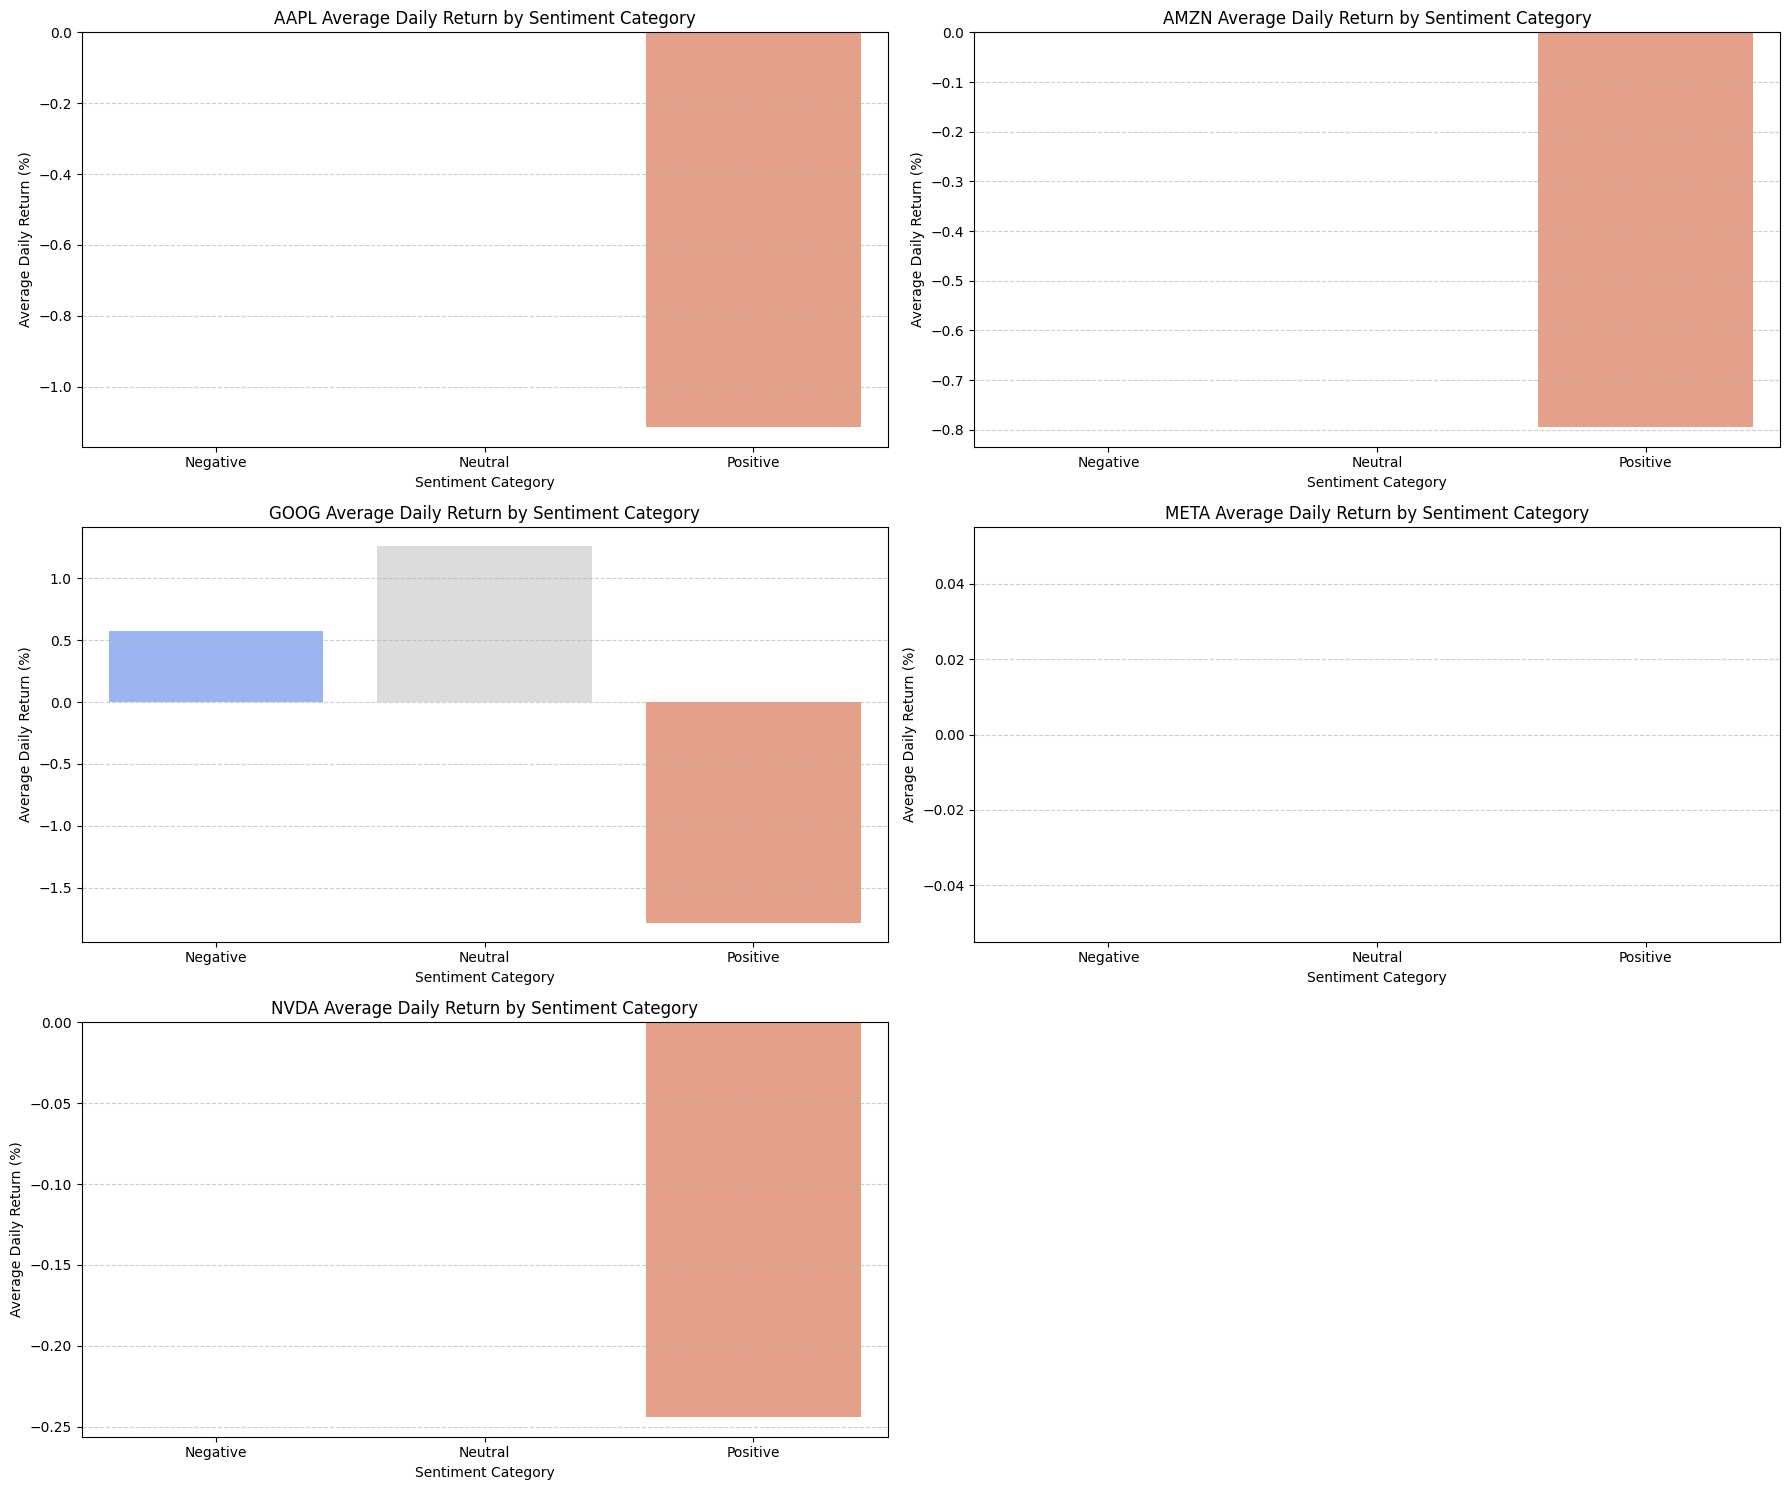

Sentiment classification and average returns plotting complete.


In [8]:
print("--- Classifying sentiment and plotting average daily returns per category ---")

plt.figure(figsize=(18, 15))

for i, stock_name in enumerate(stock_names):
    merged_df = merged_dfs[stock_name]
    
    # Classify sentiment
    # Thresholds can be adjusted
    merged_df['sentiment_category'] = pd.cut(
        merged_df['avg_daily_sentiment'],
        bins=[-1, -0.05, 0.05, 1], # Negative, Neutral, Positive
        labels=['Negative', 'Neutral', 'Positive'],
        right=True
    )

    # Calculate average daily return per sentiment category
    avg_returns_by_sentiment = merged_df.groupby('sentiment_category', observed=True)['Daily_Return_Pct'].mean().reindex(['Negative', 'Neutral', 'Positive'])

    # Create bar plot
    plt.subplot(3, 2, i + 1)
    sns.barplot(x=avg_returns_by_sentiment.index, y=avg_returns_by_sentiment.values, palette='coolwarm', hue=avg_returns_by_sentiment.index, legend=False)
    plt.title(f'{stock_name} Average Daily Return by Sentiment Category')
    plt.xlabel('Sentiment Category')
    plt.ylabel('Average Daily Return (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Sentiment classification and average returns plotting complete.")